# CMSDAS 2026 Hefei — Short Exercise: Machine Learning
# Session #3: Transformers beyond classification

Course Indico link: https://indico.cern.ch/event/1639697/timetable/?view=standard#263-machine-learning

This notebook is available on the Course [GitLab page](https://gitlab.cern.ch/das-hefei2026/exercise/-/tree/master/Short_exercise/Machine_Learning).

In [ ]:
## Install the lightning package if using SWAN/lxplus-gpu for the first time
## (uncomment and run the lines below)

# !pip install lightning --user

# import os, sys
# sys.path.append(f"{os.environ['HOME']}/.local/lib/python3.13/site-packages")

In [ ]:
import os
import uproot
import awkward as ak
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import Dataset, DataLoader
import lightning as L
import torch.nn.functional as F
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch import nn
import torchmetrics


## Part A: Adding physics-inspired variables to the Transformer

In the previous section we implemented a plain Transformer:

 - Each physics object (jet, lepton, MET) is treated as a token. Within Transformer blocks, tokens "communicate" via attention and update their latent-space representations through the FFN.
 - We defined a trainable class token that participates in this exchange. For classification, we use its final latent vector to obtain the logits.

Although our task is a simple classification—not enough to showcase the Transformer's scaling power as model size and data grow—there is still room to improve the model when handling complex inputs. How can we make the Transformer "smarter"? A practical approach is to incorporate the intrinsic structure of the data into the network design.

When two physics objects interact, can we add properties that are hard to learn from token-based features alone? One compelling variable is the invariant mass between them.

<img src="figures/token-in-classroom-pairwise-illustration.png" alt="image" width=900/>

We add this invariant mass as an attention bias so that each token attends to pairwise invariant masses when communicating with others.

### Prepare the dataset

We load the same dataset as in the previous section.

In [ ]:
# Load with Awkward: jets and leptons are per-event variable-length vectors (jagged arrays).
SIG_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/train_and_test_sig_hhbbww_1M.root:tree"
BKG_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/train_and_test_bkg_ttbar_1M.root:tree"

ak_sig = uproot.concatenate(SIG_PATH, library="ak")
ak_bkg = uproot.concatenate(BKG_PATH, library="ak")

def _round2(x):
    if isinstance(x, float):
        return round(x, 2)
    if isinstance(x, list):
        return [_round2(v) for v in x]
    return x

print("=== Inspect branches: print two events (signal file) ===\n")
for name in ak_sig.fields:
    arr = ak_sig[name]
    print(name)
    print(" ", arr.type)
    print(" ", _round2(ak.to_list(arr[1:3])))
    print()

=== Inspect branches: print two events (signal file) ===

jet_pt
  1000000 * var * float32
  [[699.22, 413.56, 234.12, 148.36, 103.56, 64.93, 44.53, 34.81, 34.17, 33.04, 20.44], [435.95, 285.27, 223.49, 18.79]]

jet_eta
  1000000 * var * float32
  [[0.0, -0.13, -1.51, -0.5, -1.07, 0.07, 1.88, 2.52, -1.45, -0.45, -2.16], [-0.16, 0.52, 0.93, 0.51]]

jet_phi
  1000000 * var * float32
  [[-0.65, 2.62, -3.06, 0.88, 0.72, 0.79, -3.13, -2.76, 1.67, -0.71, -3.0], [2.22, -1.33, -0.47, -2.65]]

jet_energy
  1000000 * var * float32
  [[706.05, 417.56, 558.76, 168.47, 169.21, 65.74, 149.02, 218.53, 77.43, 36.62, 89.48], [444.12, 325.26, 329.26, 21.68]]

jet_mass
  1000000 * var * float32
  [[97.98, 23.49, 24.38, 22.38, 14.46, 9.34, 5.39, 2.44, 7.68, 4.04, 3.93], [48.28, 21.36, 41.28, 3.96]]

jet_is_btag
  1000000 * var * int32
  [[0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0], [0, 1, 0, 1]]

lep_pt
  1000000 * var * float32
  [[257.71, 166.02], [146.31, 81.17]]

lep_eta
  1000000 * var * float32
  [[-0.08, -0.

Now, we define the dataset.

There is one difference from the previous section: to compute the invariant mass between any pair of tokens, we need each token's 4-momentum (E, px, py, pz). The dataset therefore precomputes these 4-vectors for all tokens. For MET we assume $p_z=0$ and $E=p_\mathrm{T}$.

In [ ]:
ak_events = ak.concatenate([ak_sig, ak_bkg])
labels = np.concatenate([np.ones(len(ak_sig), dtype=np.int64), np.zeros(len(ak_bkg), dtype=np.int64)])
idx_all = np.arange(len(ak_events))
train_idx, tmp_idx = train_test_split(idx_all, test_size=0.2, random_state=0)
val_idx, test_idx = train_test_split(tmp_idx, test_size=0.5, random_state=0)

# return a flattened matrix of jet features: (pt, eta, phi, E, m)
def _jet_matrix(ev, mask):
    return np.column_stack([ak.to_numpy(ak.flatten(b[mask])) for b in [ev["jet_pt"], ev["jet_eta"], ev["jet_phi"], ev["jet_energy"], ev["jet_mass"]]]).astype(np.float64)

# return a flattened matrix of lepton features: (pt, eta, phi, E, type, iso)
def _lep_matrix(ev):
    pid = ak.to_numpy(ak.flatten(ev["lep_pid"]))
    ltype = np.where(np.abs(pid) == 11, 0.0, 1.0).astype(np.float64)
    return np.column_stack([ak.to_numpy(ak.flatten(ev["lep_pt"])), ak.to_numpy(ak.flatten(ev["lep_eta"])), ak.to_numpy(ak.flatten(ev["lep_phi"])), ak.to_numpy(ak.flatten(ev["lep_energy"])), ltype, ak.to_numpy(ak.flatten(ev["lep_iso"]))]).astype(np.float64)

# convert (pt, eta, phi, E) to 4-momentum (E, px, py, pz)
def _pt_eta_phi_E_to_vec(pt, eta, phi, E):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    return np.column_stack([E, px, py, pz]).astype(np.float32)

# MET: eta=0, m=0 -> pz=0, E=pt
def _met_to_vec(pt, phi):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    return np.column_stack([pt, px, py, np.zeros_like(pt)]).astype(np.float32)

# pad jagged vectors (no scaling) for 4-momenta
def _pad_vec_jagged(matrix, counts, max_len, feat_dim=4):
    if matrix.size == 0:
        n = len(counts)
        return np.zeros((n, max_len, feat_dim), dtype=np.float32)
    jagged = ak.unflatten(ak.Array(matrix), counts, axis=0)
    padded = np.asarray(ak.fill_none(ak.pad_none(jagged, max_len, axis=1, clip=True), 0.0), dtype=np.float32)
    return padded

# scale and pad the matrix to the regular length
def _scale_pad_jagged(matrix, scaler, counts, max_len, feat_dim):
    if matrix.size == 0:
        n = len(counts)
        return np.zeros((n, max_len, feat_dim), dtype=np.float32), np.zeros((n, max_len), dtype=bool)
    scaled = scaler.transform(matrix).astype(np.float32)
    jagged = ak.unflatten(ak.Array(scaled), counts, axis=0)
    padded = np.asarray(ak.fill_none(ak.pad_none(jagged, max_len, axis=1, clip=True), 0.0), dtype=np.float32)
    masks = np.arange(max_len) < np.minimum(ak.to_numpy(counts), max_len)[:, None]
    return padded, masks


MAX_JETS, MAX_LEPS = 2, 2
train_ev = ak_events[train_idx]
is_b_tr = train_ev["jet_is_btag"] == 1
jm_tr = _jet_matrix(train_ev, is_b_tr)
lm_tr = _lep_matrix(train_ev)
jet_scaler = StandardScaler().fit(jm_tr if jm_tr.size > 0 else np.zeros((1, 5)))
lep_scaler = StandardScaler().fit(lm_tr if lm_tr.size > 0 else np.zeros((1, 6)))
met_scaler = StandardScaler().fit(np.column_stack([ak.to_numpy(train_ev["met_pt"]), ak.to_numpy(train_ev["met_phi"])]).astype(np.float64))

is_b = ak_events["jet_is_btag"] == 1
jet_mat = _jet_matrix(ak_events, is_b)
counts_j = ak.num(ak_events["jet_pt"][is_b])
jets_pre, jet_masks_pre = _scale_pad_jagged(jet_mat, jet_scaler, counts_j, MAX_JETS, 5)

lep_mat = _lep_matrix(ak_events)
counts_l = ak.num(ak_events["lep_pt"])
leps_pre, lep_masks_pre = _scale_pad_jagged(lep_mat, lep_scaler, counts_l, MAX_LEPS, 6)

mets_pre = met_scaler.transform(np.column_stack([ak.to_numpy(ak_events["met_pt"]), ak.to_numpy(ak_events["met_phi"])]).astype(np.float64)).astype(np.float32)

# 4-momenta (E, px, py, pz) for attention bias; raw values, no scaling
jet_vec_mat = _pt_eta_phi_E_to_vec(jet_mat[:, 0], jet_mat[:, 1], jet_mat[:, 2], jet_mat[:, 3])
lep_vec_mat = _pt_eta_phi_E_to_vec(lep_mat[:, 0], lep_mat[:, 1], lep_mat[:, 2], lep_mat[:, 3])
jet_vec_pre = _pad_vec_jagged(jet_vec_mat, counts_j, MAX_JETS, 4)
lep_vec_pre = _pad_vec_jagged(lep_vec_mat, counts_l, MAX_LEPS, 4)
met_vec_pre = _met_to_vec(ak.to_numpy(ak_events["met_pt"]), ak.to_numpy(ak_events["met_phi"]))


class EventDataset(Dataset):
    """Lightweight dataset: takes precomputed arrays; __getitem__ only indexes. No custom collate_fn needed."""

    def __init__(self, indices, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre,
                 jet_vec_pre, lep_vec_pre, met_vec_pre, labels):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.jets_pre = jets_pre
        self.leps_pre = leps_pre
        self.mets_pre = mets_pre
        self.jet_masks_pre = jet_masks_pre
        self.lep_masks_pre = lep_masks_pre
        self.jet_vec_pre = jet_vec_pre
        self.lep_vec_pre = lep_vec_pre
        self.met_vec_pre = met_vec_pre
        self.labels = labels

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = int(self.indices[idx])
        batch_dict = {
            "jet": torch.from_numpy(self.jets_pre[i].copy()),
            "lep": torch.from_numpy(self.leps_pre[i].copy()),
            "met": torch.from_numpy(self.mets_pre[i].copy()),
            "jet_mask": torch.from_numpy(self.jet_masks_pre[i].copy()),
            "lep_mask": torch.from_numpy(self.lep_masks_pre[i].copy()),
            "jet_vec": torch.from_numpy(self.jet_vec_pre[i].copy()),
            "lep_vec": torch.from_numpy(self.lep_vec_pre[i].copy()),
            "met_vec": torch.from_numpy(self.met_vec_pre[i].copy()),
        }
        return batch_dict, int(self.labels[i])

In [ ]:
# Example: sample one event
dataset_example = EventDataset(train_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre,
                               jet_vec_pre, lep_vec_pre, met_vec_pre, labels)
batch_dict, label = dataset_example[0]
jet_features = batch_dict["jet"]
lep_features = batch_dict["lep"]
met_features = batch_dict["met"]
jet_vec = batch_dict["jet_vec"]
lep_vec = batch_dict["lep_vec"]
met_vec = batch_dict["met_vec"]

event_idx = int(dataset_example.indices[0])
event = ak_events[event_idx]
print(f"Sample event (index {event_idx}): label={label} ({'signal' if label else 'background'})")
print(f"  Shapes: jets {jet_features.shape}, leps {lep_features.shape}, met {met_features.shape}")
print("  Jets (pt, eta, phi, E, m):")
for j in range(jet_features.shape[0]):
    print(f"    jet {j}: {[round(x.item(), 2) for x in jet_features[j]]}")
print("  Leptons (pt, eta, phi, E, type, iso):")
for k in range(lep_features.shape[0]):
    print(f"    lep {k}: {[round(x.item(), 2) for x in lep_features[k]]}")
print(f"  MET: pt={met_features[0].item():.2f}, phi={met_features[1].item():.2f}")

print("  Jet vectors (E, px, py, pz):")
for j in range(jet_vec.shape[0]):
    print(f"    jet {j}: {[round(x.item(), 2) for x in jet_vec[j]]}")
print("  Lepton vectors (E, px, py, pz):")
for k in range(lep_vec.shape[0]):
    print(f"    lep {k}: {[round(x.item(), 2) for x in lep_vec[k]]}")
print(f"  MET vector (E, px, py, pz): {[round(x.item(), 2) for x in met_vec]}")
print("  Raw event (before scaling): n_jets={}, n_leps={}".format(len(event["jet_pt"]), len(event["lep_pt"])))

Sample event (index 608812): label=1 (signal)
  Shapes: jets torch.Size([2, 5]), leps torch.Size([2, 6]), met torch.Size([2])
  Jets (pt, eta, phi, E, m):
    jet 0: [3.0, -0.78, -1.54, 2.14, 1.51]
    jet 1: [-0.63, -0.89, -1.01, -0.6, -0.51]
  Leptons (pt, eta, phi, E, type, iso):
    lep 0: [2.91, -0.41, -1.23, 1.49, -1.08, -0.04]
    lep 1: [0.83, -0.17, -1.24, 0.1, -1.08, -0.05]
  MET: pt=1.37, phi=-1.10
  Jet vectors (E, px, py, pz):
    jet 0: [506.4, -342.93, -125.82, -349.59]
    jet 1: [64.06, -10.58, -40.77, -47.8]
  Lepton vectors (E, px, py, pz):
    lep 0: [245.87, -137.36, -178.88, -97.9]
    lep 1: [112.59, -70.23, -85.81, -19.51]
  MET vector (E, px, py, pz): [221.65, -90.97, -202.13, 0.0]
  Raw event (before scaling): n_jets=4, n_leps=2


Initiate the dataset and data loader.

In [ ]:
train_ds_tfm = EventDataset(train_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre,
                            jet_vec_pre, lep_vec_pre, met_vec_pre, labels)
val_ds_tfm = EventDataset(val_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre,
                          jet_vec_pre, lep_vec_pre, met_vec_pre, labels)
train_loader_tfm = DataLoader(train_ds_tfm, batch_size=1024, num_workers=4, shuffle=True)
val_loader_tfm = DataLoader(val_ds_tfm, batch_size=1024, num_workers=4, shuffle=False)

### Build the Transformer with attention bias

#### Embedding layer
The embedding layer is unchanged from the previous section.


In [ ]:
def to_m2(p, eps=1e-8):
    """Invariant mass squared from 4-momentum (E, px, py, pz). p: (..., 4). Returns (..., 1)."""
    E, px, py, pz = p[..., 0], p[..., 1], p[..., 2], p[..., 3]
    m2 = E * E - px * px - py * py - pz * pz
    return m2.clamp(min=eps).unsqueeze(-1)

class Embed(nn.Module):
    """Three MLPs: jet (5), lepton (6), MET (2). Sequence: [CLS] + all jets + all leptons + MET."""

    def __init__(self, config):
        super().__init__()
        d = config.hidden_size
        self.jet_emb = nn.Sequential(nn.Linear(5, d), nn.GELU(), nn.Linear(d, d))
        self.lep_emb = nn.Sequential(nn.Linear(6, d), nn.GELU(), nn.Linear(d, d))
        self.met_emb = nn.Sequential(nn.Linear(2, d), nn.GELU(), nn.Linear(d, d))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d))
        self.norm = nn.LayerNorm(d)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, jet, lep, met, jet_mask, lep_mask):
        # Input shapes:
        #   jet: (B, Nj, 5)   – batch, max jets, features (pt, eta, phi, E, m)
        #   lep: (B, Nl, 6)   – batch, max leptons, features (pt, eta, phi, E, type, iso)
        #   met: (B, 2)       – batch, features (pt, phi)
        #   jet_mask: (B, Nj) – True = real jet (non-padded)
        #   lep_mask: (B, Nl) – True = real lepton (non-padded)

        B = jet.size(0)
        hj = self.jet_emb(jet)
        hl = self.lep_emb(lep)
        hm = self.met_emb(met).unsqueeze(1)
        cls = self.cls_token.expand(B, -1, -1)

        # concat tokens: [CLS] + all jets + all leptons + MET
        x = torch.cat([cls, hj, hl, hm], dim=1)
        
        # key_padding_mask: True = ignore in attention (padded jet/lepton positions)
        jet_padding_mask = ~jet_mask
        lep_padding_mask = ~lep_mask
        key_padding_mask = torch.cat(
            [
                torch.zeros(B, 1, dtype=torch.bool, device=jet.device),
                jet_padding_mask,
                lep_padding_mask,
                torch.zeros(B, 1, dtype=torch.bool, device=jet.device),
            ],
            dim=1,
        )
        x = self.norm(x)
        x = self.dropout(x)
        return x, key_padding_mask

#### Transformer block
The Transformer block is unchanged, but we add an attention bias via the `attn_mask` parameter of `MultiheadAttention`. When provided as a float tensor, it is added directly to the N×N attention (N=number of tokens) scores before the softmax.

In [ ]:
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, attn_dropout=0.1, dropout=0.1):
        super(TransformerBlock, self).__init__()
        # Multi-head self-attention layer
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=attn_dropout, batch_first=True)
        # First layer normalization (applied before attention)
        self.norm1 = nn.LayerNorm(embed_dim)
        # Feed-forward network: two linear layers with GELU activation in between
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.GELU(),
            nn.Linear(ff_hidden_dim, embed_dim),
        )
        # Second layer normalization (applied before feed-forward)
        self.norm2 = nn.LayerNorm(embed_dim)
        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None, attn_mask=None):
        # Apply first layer normalization before self-attention
        x = self.norm1(x)
        # Self-attention: Q, K, V are all set to x (self-attention).
        # key_padding_mask: True at padded jet/lepton positions (ignored by attention).
        # attn_mask: additive bias (e.g. pairwise features) added to attention scores.
        attn_output, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
        # Add & Norm: residual connection after attention + dropout
        x = x + self.dropout(attn_output)

        # Apply second layer normalization before feed-forward
        x = self.norm2(x)
        # Feed-forward network
        ff_output = self.ff(x)
        # Add & Norm: residual connection after feed-forward + dropout
        x = x + self.dropout(ff_output)

        return x

#### Transformer network
The network adds a `get_attention_bias` method that computes log(m²+1) for each pair of tokens and embeds it as an attention bias.

In [ ]:
class TransformerNet(nn.Module):
    def __init__(self, config):
        super().__init__()
        # Embedding layer: jagged jets/leptons + MET -> token sequence
        self.embed = Embed(config)
        # Stack of transformer blocks
        self.blocks = nn.ModuleList(
            [
                TransformerBlock(
                    config.hidden_size,
                    config.num_attention_heads,
                    config.intermediate_size,
                    attn_dropout=config.attn_dropout_prob,
                    dropout=config.hidden_dropout_prob,
                )
                for _ in range(config.num_hidden_layers)
            ]
        )
        # Dropout before final classification
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # Final linear layer for classification
        self.head = nn.Linear(config.hidden_size, config.num_labels)
        self.use_attention_bias = getattr(config, "use_attention_bias", False)

        if self.use_attention_bias:
            pair_hidden_size = getattr(config, "pair_hidden_size", config.hidden_size)
            self.pair_embedding = nn.Sequential(
                nn.Linear(1, pair_hidden_size),
                nn.GELU(),
                nn.Linear(pair_hidden_size, config.num_attention_heads),
            )

    def get_attention_bias(self, vectors):
        """Compute pairwise log(m^2+1) and embed as attention bias. vectors: (B, num_tokens, 4) in (E, px, py, pz)."""
        # Prepend zero vector for [CLS] token
        v = torch.cat([torch.zeros_like(vectors[:, :1]), vectors], dim=1)  # (B, 1+num_tokens, 4)
        # Pairwise sum: v_i + v_j for all pairs
        # v.unsqueeze(-2): (B, T, 1, 4), v.unsqueeze(-3): (B, 1, T, 4)
        pair_sum = v.unsqueeze(-2) + v.unsqueeze(-3)  # (B, T, T, 4)
        lnm2 = torch.log(to_m2(pair_sum, eps=1e-8) + 1)  # (B, T, T, 1)
        # pair_embedding: (B, T, T, 1) -> (B, T, T, num_heads), then permute to (B, num_heads, T, T)
        out = self.pair_embedding(lnm2).permute(0, 3, 1, 2)  # (B, num_heads, T, T)
        # Reshape for MultiheadAttention: (B*num_heads, T, T)
        return out.reshape(-1, v.size(1), v.size(1))

    def forward(self, batch):
        jet, lep, met = batch["jet"], batch["lep"], batch["met"]
        jet_mask, lep_mask = batch["jet_mask"], batch["lep_mask"]
        # Pass input through embedding layer (also builds padding mask for attention)
        x, key_padding_mask = self.embed(jet, lep, met, jet_mask, lep_mask)
        # Build 4-vectors: [CLS zero] + jet_vec + lep_vec + met_vec, in the same order as tokens
        attn_mask = None
        if self.use_attention_bias:
            jet_vec = batch["jet_vec"]   # (B, Nj, 4)
            lep_vec = batch["lep_vec"]   # (B, Nl, 4)
            met_vec = batch["met_vec"]   # (B, 4)
            vectors = torch.cat([jet_vec, lep_vec, met_vec.unsqueeze(1)], dim=1)  # (B, Nj+Nl+1, 4)
            attn_mask = self.get_attention_bias(vectors)
        # Pass through each transformer block
        for block in self.blocks:
            x = block(x, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
        # Select the hidden state corresponding to the [CLS] token (first token)
        x = x[:, 0, :]
        # Apply dropout
        x = self.dropout(x)
        # Final classification layer
        return self.head(x)

We define the LightningModule and start training below. The `use_attention_bias` parameter controls whether to use invariant mass as an attention bias; set it to False to disable.


In [ ]:
from types import SimpleNamespace
config = SimpleNamespace(
    hidden_size = 16,          # Hidden size for embeddings and Transformer
    num_attention_heads = 4,   # Number of attention heads
    intermediate_size = 32,    # Feed-forward intermediate size
    num_hidden_layers = 4,     # Number of Transformer layers
    hidden_dropout_prob = 0.,  # Dropout probability
    attn_dropout_prob = 0.,    # Attention dropout probability
    num_labels = 2,            # Number of output classes
    use_attention_bias = True, # Include pairwise invariant mass^2 as attention bias
    pair_hidden_size = 16,     # Hidden size for pair embedding
)

class LitTransformer(L.LightningModule):
    def __init__(self, config):
        super().__init__()
        self.mod = TransformerNet(config)
        self.train_acc = torchmetrics.Accuracy(task="multiclass", num_classes=config.num_labels)
        self.val_acc = torchmetrics.Accuracy(task="multiclass", num_classes=config.num_labels)

    def forward(self, batch):
        return self.mod(batch)

    def training_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.train_acc(logits, y)
        self.log("train_loss", loss)
        self.log("train_acc", self.train_acc, on_step=False, on_epoch=True)
        self.log("lr", self.trainer.optimizers[0].param_groups[0]["lr"])
        return loss

    def validation_step(self, batch, batch_idx):
        x, y = batch
        logits = self(x)
        loss = F.cross_entropy(logits, y)
        self.val_acc(logits, y)
        self.log("val_loss", loss)
        self.log("val_acc", self.val_acc, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=0.01)

        def lr_lambda(epoch):
            if epoch < 0.7 * self.trainer.max_epochs:
                return 1.0
            decay_factor = (epoch - 0.7 * self.trainer.max_epochs) / (0.3 * self.trainer.max_epochs)
            return 0.01 ** decay_factor

        scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
        return [optimizer], [scheduler]


model_transformer = LitTransformer(config)
print(model_transformer)  # Self-check: verify that each part of the model is wired correctly

LitTransformer(
  (mod): TransformerNet(
    (embed): Embed(
      (jet_emb): Sequential(
        (0): Linear(in_features=5, out_features=16, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
      (lep_emb): Sequential(
        (0): Linear(in_features=6, out_features=16, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
      (met_emb): Sequential(
        (0): Linear(in_features=2, out_features=16, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
      (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
   

#### Start training

In [ ]:
# Trainer with a TensorBoard logger (you may change the run name in the logger)
trainer = L.Trainer(accelerator="gpu", devices=1, max_epochs=20, logger=L.pytorch.loggers.TensorBoardLogger("tb_logs", name="pairwise_mass_transformer"))

# Fit the model (jagged jet/lepton + MET loaders)
trainer.fit(model_transformer, train_loader_tfm, val_loader_tfm)

### Performance evaluation

We use the trained model to perform inference on the test set and obtain predictions.


In [ ]:
test_ds_tfm = EventDataset(test_idx, jets_pre, leps_pre, mets_pre, jet_masks_pre, lep_masks_pre,
                           jet_vec_pre, lep_vec_pre, met_vec_pre, labels)
test_loader_tfm = DataLoader(test_ds_tfm, batch_size=1024, shuffle=False)

# If your model is saved, load it
# model_transformer = LitTransformer.load_from_checkpoint('path_to_checkpoint.ckpt', config=config)

# Inference on test set
model_transformer.eval()
all_logits = []
with torch.no_grad():
    for batch, _ in test_loader_tfm:
        logits = model_transformer(batch)
        all_logits.append(logits.cpu().numpy())
test_logits = np.concatenate(all_logits, axis=0)

# Apply softmax to get probabilities (signal = class 1)
test_score = np.exp(test_logits[:, 1]) / (np.exp(test_logits[:, 0]) + np.exp(test_logits[:, 1]))
test_labels = labels[test_idx]

/home/licq/utils/miniconda3/envs/weaver-uproot5/lib/python3.9/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Plot the ROC curve and compare it with the previous results.

- Does the Transformer with pairwise mass improve over the plain Transformer?
- Compare the training curves in TensorBoard—what do you observe?


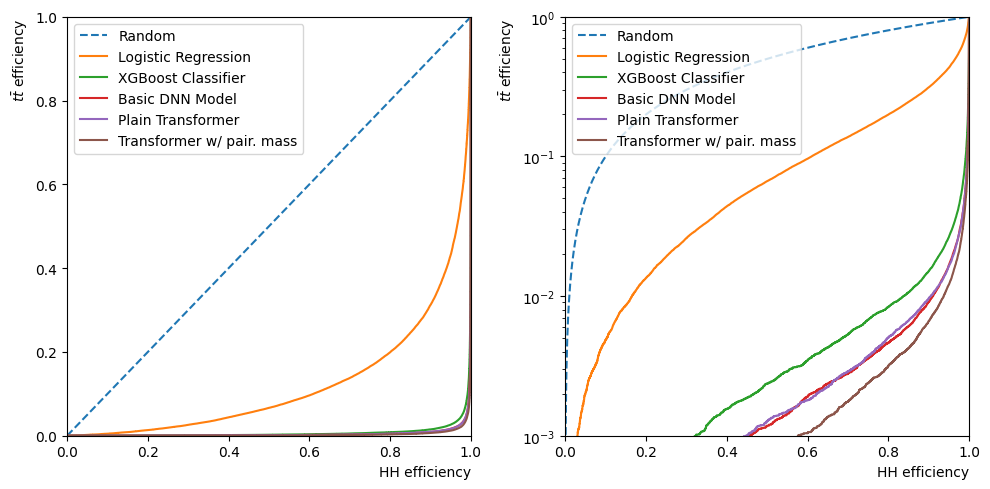

In [ ]:
# Draw the ROC curve (linear + log, compare with LR/XGB if data exist)
import sklearn.metrics as m
fpr, tpr, _thres = m.roc_curve(test_labels, test_score)

f = plt.figure(figsize=(10, 5), tight_layout=True)
ax1 = f.add_subplot(1, 2, 1)
ax2 = f.add_subplot(1, 2, 2)

for ax, ax_type in zip([ax1, ax2], ['linear', 'log']):
    ax.plot(np.linspace(0, 1, 1000), np.linspace(0, 1, 1000), '--', label='Random')
    dat = np.loadtxt("data/roc_lr.dat")
    tpr_clf, fpr_clf = (dat[0], dat[1])
    ax.plot(tpr_clf, fpr_clf, label='Logistic Regression')

    dat = np.loadtxt("data/roc_xgb.dat")
    tpr_xgb, fpr_xgb = (dat[0], dat[1])
    ax.plot(tpr_xgb, fpr_xgb, label='XGBoost Classifier')
    
    dat = np.loadtxt("data/roc_dnn.dat")
    tpr_dnn, fpr_dnn = (dat[0], dat[1])
    ax.plot(tpr_dnn, fpr_dnn, label='Basic DNN Model')

    dat = np.loadtxt("data/roc_transformer.dat")
    tpr_tfm, fpr_tfm = (dat[0], dat[1])
    ax.plot(tpr_tfm, fpr_tfm, label='Plain Transformer')

    ax.plot(tpr, fpr, label=f'Transformer w/ pair. mass')
    if ax_type == 'linear':
        ax.set_xlim(0, 1)
        ax.set_ylim(0, 1)
    elif ax_type == 'log':
        ax.set_xlim(0, 1)
        ax.set_ylim(1e-3, 1)
        ax.set_yscale('log')
    ax.set_xlabel('HH efficiency', ha='right', x=1.0)
    ax.set_ylabel(r'$t\bar{t}$ efficiency', ha='right', y=1.0)
    ax.legend()

plt.show()

Save the ROC curve data.

In [ ]:
os.makedirs('data', exist_ok=True)
np.savetxt(f"data/pairwise_mass_transformer.dat", [tpr, fpr])

# Part B: Jet assignment for $HH\to 4b$: a physics task distinct from classification.

In the same HH analysis context, for the $HH\to 4b$ final state we have four jets. Unlike $bbWW$, once we have four jets, how do we reconstruct which two jets form a pair from each Higgs? Some analyses therefore consider a jet-assignment task, which aids Higgs reconstruction and provides a fit observable for the final mass measurement.

We use the Transformer with pairwise mass from Part A to tackle this task.

## Our dataset

The training sample is a simulated $HH\to 4b$ sample with variable Higgs masses (not physical data). The goal is to train the jet-assignment network to pair jets correctly regardless of the Higgs mass, rather than relying on invariant mass peaks near 125 GeV. If we relied on the latter, the network would always pair the two jets whose invariant mass is closest to 125 GeV—which would bias even background events (e.g. four b-jets from QCD radiation) toward selecting a 125 GeV pair and distort the final mass spectrum.


### Inspect the dataset

In [ ]:
TRAIN_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/train_hh4b_var_mass_1M.root:tree"
TEST_PATH = "/eos/user/c/coli/cms-repo/cmsdas/data/test_hh4b_sm_200k.root:tree"

ak_train = uproot.concatenate(TRAIN_PATH, library="ak")


def _round2(x):
    if isinstance(x, float):
        return round(x, 2)
    if isinstance(x, list):
        return [_round2(v) for v in x]
    return x


print("=== Inspect branches: print two events (train file) ===\n")
for name in ak_train.fields:
    arr = ak_train[name]
    print(name)
    print(" ", arr.type)
    print(" ", _round2(ak.to_list(arr[:2])))
    print()

=== Inspect branches: print two events (train file) ===

gen_higgs1_pt
  1000000 * float32
  [196.57, 192.7]

gen_higgs1_eta
  1000000 * float32
  [-0.57, -1.51]

gen_higgs1_phi
  1000000 * float32
  [-0.73, -1.39]

gen_higgs1_mass
  1000000 * float32
  [200.0, 200.0]

gen_higgs2_pt
  1000000 * float32
  [189.7, 196.95]

gen_higgs2_eta
  1000000 * float32
  [-1.07, -1.75]

gen_higgs2_phi
  1000000 * float32
  [2.09, 1.75]

gen_higgs2_mass
  1000000 * float32
  [95.0, 95.0]

jet_pt
  1000000 * var * float32
  [[170.05, 163.89, 81.7, 51.37], [168.53, 114.72, 73.64, 62.5]]

jet_eta
  1000000 * var * float32
  [[-0.95, -0.7, 0.53, 0.35], [-1.28, -1.95, -1.07, -1.23]]

jet_phi
  1000000 * var * float32
  [[2.07, -1.1, -2.7, 0.38], [-0.91, 1.97, -2.63, 1.44]]

jet_energy
  1000000 * var * float32
  [[254.37, 206.36, 94.62, 55.15], [327.17, 411.14, 120.42, 115.7]]

jet_mass
  1000000 * var * float32
  [[23.64, 13.3, 15.2, 7.9], [13.48, 9.37, 9.6, 5.48]]

jet_is_btag
  1000000 * var * int32
  

As can be found:

 - The dataset stores variables for all jets. Most events have 4–8 jets, so many jets come from QCD radiation.
 - The `jet_is_btag` variable indicates whether a jet is successfully tagged by the b-tagger.
 - The `jet_gen_higgs1_label` and `jet_gen_higgs2_label` variables are generator-level (known only in simulation). They indicate whether a jet truly comes from Higgs 1 or 2 decay, or from another source. We define the Higgs with larger η as Higgs 1 and the one with smaller η as Higgs 2.

### Prepare the dataset

Data loading is similar with the classification setup but **uses jets only** (no leptons or MET).
Input features are (pt, eta, phi, E, m, is_btag), with up to 8 jets per event.
Training and validation are split from the training file; the test set is loaded from a separate file corresponding to the Standard Model HH->4b process with Higgs mass 125 GeV.


In [ ]:
# Helpers: jet matrix (pt, eta, phi, E, m, is_btag), 4-momentum conversion, scale/pad
def _jet_matrix(ev):
    """Return flattened jet features (pt, eta, phi, E, m, is_btag) for all jets in event array."""
    return np.column_stack([
        ak.to_numpy(ak.flatten(ev["jet_pt"])),
        ak.to_numpy(ak.flatten(ev["jet_eta"])),
        ak.to_numpy(ak.flatten(ev["jet_phi"])),
        ak.to_numpy(ak.flatten(ev["jet_energy"])),
        ak.to_numpy(ak.flatten(ev["jet_mass"])),
        ak.to_numpy(ak.flatten(ev["jet_is_btag"])).astype(np.float64),
    ]).astype(np.float64)


def _pt_eta_phi_E_to_vec(pt, eta, phi, E):
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    return np.column_stack([E, px, py, pz]).astype(np.float32)


def _pad_vec_jagged(matrix, counts, max_len, feat_dim=4):
    if matrix.size == 0:
        n = len(counts)
        return np.zeros((n, max_len, feat_dim), dtype=np.float32)
    jagged = ak.unflatten(ak.Array(matrix), counts, axis=0)
    arr = ak.fill_none(ak.pad_none(jagged, max_len, axis=1, clip=True), 0.0)
    out = ak.to_numpy(arr, allow_missing=True)
    return np.asarray(out.filled(0.0) if isinstance(out, np.ma.MaskedArray) else out, dtype=np.float32)


def _scale_pad_jagged(matrix, scaler, counts, max_len, feat_dim):
    if matrix.size == 0:
        n = len(counts)
        return np.zeros((n, max_len, feat_dim), dtype=np.float32), np.zeros((n, max_len), dtype=bool)
    scaled = scaler.transform(matrix).astype(np.float32)
    jagged = ak.unflatten(ak.Array(scaled), counts, axis=0)
    arr = ak.fill_none(ak.pad_none(jagged, max_len, axis=1, clip=True), 0.0)
    out = ak.to_numpy(arr, allow_missing=True)
    padded = np.asarray(out.filled(0.0) if isinstance(out, np.ma.MaskedArray) else out, dtype=np.float32)
    masks = np.arange(max_len) < np.minimum(ak.to_numpy(counts), max_len)[:, None]
    return padded, masks


def _pad_labels_jagged(labels_flat, counts, max_len, fill_value=-100):
    """Pad per-jet labels; use fill_value for padded positions (ignored in CE loss via ignore_index)."""
    if labels_flat.size == 0:
        n = len(counts)
        return np.full((n, max_len), fill_value, dtype=np.int64)
    jagged = ak.unflatten(ak.Array(labels_flat), counts, axis=0)
    arr = ak.fill_none(ak.pad_none(jagged, max_len, axis=1, clip=True), fill_value)
    out = ak.to_numpy(arr, allow_missing=True)
    return np.asarray(out.filled(fill_value) if isinstance(out, np.ma.MaskedArray) else out, dtype=np.int64)


MAX_JETS = 8

# Train/val split from training file
idx_all = np.arange(len(ak_train))
train_idx, val_idx = train_test_split(idx_all, test_size=0.2, random_state=0)

train_ev = ak_train[train_idx]
jet_mat_tr = _jet_matrix(train_ev)
counts_j_tr = ak.num(train_ev["jet_pt"])
jet_scaler = StandardScaler().fit(jet_mat_tr if jet_mat_tr.size > 0 else np.zeros((1, 6)))

# Preprocess training data
jet_mat_train = _jet_matrix(ak_train)
counts_j_train = ak.num(ak_train["jet_pt"])
jets_train, jet_masks_train = _scale_pad_jagged(
    jet_mat_train, jet_scaler, counts_j_train, MAX_JETS, 6
)
jet_vec_train = _pad_vec_jagged(
    _pt_eta_phi_E_to_vec(
        jet_mat_train[:, 0], jet_mat_train[:, 1],
        jet_mat_train[:, 2], jet_mat_train[:, 3]
    ),
    counts_j_train, MAX_JETS, 4
)
label_h1_train = _pad_labels_jagged(
    ak.to_numpy(ak.flatten(ak_train["jet_gen_higgs1_label"])),
    counts_j_train, MAX_JETS, fill_value=-100
)
label_h2_train = _pad_labels_jagged(
    ak.to_numpy(ak.flatten(ak_train["jet_gen_higgs2_label"])),
    counts_j_train, MAX_JETS, fill_value=-100
)

# Load test file
ak_test = uproot.concatenate(TEST_PATH, library="ak")
jet_mat_test = _jet_matrix(ak_test)
counts_j_test = ak.num(ak_test["jet_pt"])
jets_test, jet_masks_test = _scale_pad_jagged(
    jet_mat_test, jet_scaler, counts_j_test, MAX_JETS, 6
)
jet_vec_test = _pad_vec_jagged(
    _pt_eta_phi_E_to_vec(
        jet_mat_test[:, 0], jet_mat_test[:, 1],
        jet_mat_test[:, 2], jet_mat_test[:, 3]
    ),
    counts_j_test, MAX_JETS, 4
)
label_h1_test = _pad_labels_jagged(
    ak.to_numpy(ak.flatten(ak_test["jet_gen_higgs1_label"])),
    counts_j_test, MAX_JETS, fill_value=-100
)
label_h2_test = _pad_labels_jagged(
    ak.to_numpy(ak.flatten(ak_test["jet_gen_higgs2_label"])),
    counts_j_test, MAX_JETS, fill_value=-100
)

The below `JetAssignmentDataset` provides token-based inputs: up to 8 jets (padded to 8), each jet's 4-momentum vector, and per-jet labels (0 or 1) as training targets. The jet_mask indicates which jets are real and which are padded.

In [ ]:
class JetAssignmentDataset(Dataset):
    """Dataset for jet assignment: jets + per-jet labels (higgs1, higgs2)."""

    def __init__(self, indices, jets_pre, jet_masks_pre, jet_vec_pre, label_h1, label_h2):
        self.indices = np.asarray(indices, dtype=np.int64)
        self.jets_pre = jets_pre
        self.jet_masks_pre = jet_masks_pre
        self.jet_vec_pre = jet_vec_pre
        self.label_h1 = label_h1
        self.label_h2 = label_h2

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        i = int(self.indices[idx])
        return {
            "jet": torch.from_numpy(self.jets_pre[i].copy()),
            "jet_mask": torch.from_numpy(self.jet_masks_pre[i].copy()),
            "jet_vec": torch.from_numpy(self.jet_vec_pre[i].copy()),
            "label_h1": torch.from_numpy(self.label_h1[i].copy()),
            "label_h2": torch.from_numpy(self.label_h2[i].copy()),
        }

Initialize the datasets and data loaders.

In [ ]:
train_ds = JetAssignmentDataset(
    train_idx, jets_train, jet_masks_train, jet_vec_train, label_h1_train, label_h2_train
)
val_ds = JetAssignmentDataset(
    val_idx, jets_train, jet_masks_train, jet_vec_train, label_h1_train, label_h2_train
)
test_idx_arr = np.arange(len(ak_test))
test_ds = JetAssignmentDataset(
    test_idx_arr, jets_test, jet_masks_test, jet_vec_test, label_h1_test, label_h2_test
)

train_loader = DataLoader(train_ds, batch_size=512, num_workers=4, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=512, num_workers=4, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=512, num_workers=4, shuffle=False)

## Transformer model for jet assignment

The model uses the same architecture as the classification setup (pairwise mass attention bias) but adds token-level prediction heads. For each jet token we predict two binary targets: `jet_gen_higgs1_label` and `jet_gen_higgs2_label`. Unlike the classification case, we do not use the class token for a single prediction; instead, we apply two classification tasks (Higgs 1 and Higgs 2 labels) to each jet token, as shown below.

<img src="figures/jet-assignment-cartoon.png" alt="image" width=900/>

In [ ]:
def to_m2(p, eps=1e-8):
    """Invariant mass squared from 4-momentum (E, px, py, pz). p: (..., 4). Returns (..., 1)."""
    E, px, py, pz = p[..., 0], p[..., 1], p[..., 2], p[..., 3]
    m2 = E * E - px * px - py * py - pz * pz
    return m2.clamp(min=eps).unsqueeze(-1)


class JetEmbed(nn.Module):
    """Jet embedding only. Sequence: [CLS] + all jets."""

    def __init__(self, config):
        super().__init__()
        d = config.hidden_size
        self.jet_emb = nn.Sequential(nn.Linear(6, d), nn.GELU(), nn.Linear(d, d))
        self.cls_token = nn.Parameter(torch.randn(1, 1, d))
        self.norm = nn.LayerNorm(d)
        self.dropout = nn.Dropout(config.hidden_dropout_prob)

    def forward(self, jet, jet_mask):
        # Input shapes:
        #   jet: (B, Nj, 6)   – batch, max jets, features (pt, eta, phi, E, m, is_btag)
        #   jet_mask: (B, Nj) – True = real jet (non-padded)

        B = jet.size(0)
        hj = self.jet_emb(jet)
        cls = self.cls_token.expand(B, -1, -1)

        # Concatenate tokens: [CLS] + all jets
        x = torch.cat([cls, hj], dim=1)

        # key_padding_mask: True = ignore in attention (padded jet positions)
        key_padding_mask = torch.cat(
            [torch.zeros(B, 1, dtype=torch.bool, device=jet.device), ~jet_mask],
            dim=1,
        )
        x = self.norm(x)
        x = self.dropout(x)
        return x, key_padding_mask


class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, num_heads, ff_hidden_dim, attn_dropout=0.1, dropout=0.1):
        super(TransformerBlock, self).__init__()
        # Multi-head self-attention layer
        self.attention = nn.MultiheadAttention(embed_dim, num_heads, dropout=attn_dropout, batch_first=True)
        # First layer normalization (applied before attention)
        self.norm1 = nn.LayerNorm(embed_dim)
        # Feed-forward network: two linear layers with GELU activation in between
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, ff_hidden_dim),
            nn.GELU(),
            nn.Linear(ff_hidden_dim, embed_dim),
        )
        # Second layer normalization (applied before feed-forward)
        self.norm2 = nn.LayerNorm(embed_dim)
        # Dropout layer for regularization
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, key_padding_mask=None, attn_mask=None):
        # Apply first layer normalization before self-attention
        x = self.norm1(x)
        # Self-attention: Q, K, V are all set to x (self-attention).
        # key_padding_mask: True at padded jet positions (ignored by attention).
        # attn_mask: additive bias (e.g. pairwise features) added to attention scores.
        attn_output, _ = self.attention(x, x, x, key_padding_mask=key_padding_mask, attn_mask=attn_mask)
        # Add & Norm: residual connection after attention + dropout
        x = x + self.dropout(attn_output)

        # Apply second layer normalization before feed-forward
        x = self.norm2(x)
        # Feed-forward network
        ff_output = self.ff(x)
        # Add & Norm: residual connection after feed-forward + dropout
        x = x + self.dropout(ff_output)

        return x


class JetAssignmentTransformer(nn.Module):
    """Transformer with pairwise mass bias; token-level heads for jet_gen_higgs1_label and jet_gen_higgs2_label."""

    def __init__(self, config):
        super().__init__()
        # Embedding layer: jets -> token sequence [CLS] + jets
        self.embed = JetEmbed(config)
        # Stack of transformer blocks
        self.blocks = nn.ModuleList([
            TransformerBlock(
                config.hidden_size,
                config.num_attention_heads,
                config.intermediate_size,
                attn_dropout=config.attn_dropout_prob,
                dropout=config.hidden_dropout_prob,
            )
            for _ in range(config.num_hidden_layers)
        ])
        # Dropout before token-level prediction
        self.dropout = nn.Dropout(config.hidden_dropout_prob)
        # Token-level heads: each jet -> binary prediction (0 or 1) for higgs1 and higgs2
        self.head_h1 = nn.Linear(config.hidden_size, 2)
        self.head_h2 = nn.Linear(config.hidden_size, 2)
        self.use_attention_bias = getattr(config, "use_attention_bias", True)

        if self.use_attention_bias:
            pair_hidden_size = getattr(config, "pair_hidden_size", config.hidden_size)
            self.pair_embedding = nn.Sequential(
                nn.Linear(1, pair_hidden_size),
                nn.GELU(),
                nn.Linear(pair_hidden_size, config.num_attention_heads),
            )

    def get_attention_bias(self, vectors):
        """Compute pairwise log(m^2+1) and embed as attention bias. vectors: (B, num_jets, 4) in (E, px, py, pz)."""
        # Prepend zero vector for [CLS] token
        v = torch.cat([torch.zeros_like(vectors[:, :1]), vectors], dim=1)  # (B, 1+Nj, 4)
        # Pairwise sum: v_i + v_j for all pairs
        # v.unsqueeze(-2): (B, T, 1, 4), v.unsqueeze(-3): (B, 1, T, 4)
        pair_sum = v.unsqueeze(-2) + v.unsqueeze(-3)  # (B, T, T, 4)
        lnm2 = torch.log(to_m2(pair_sum, eps=1e-8) + 1)  # (B, T, T, 1)
        # pair_embedding: (B, T, T, 1) -> (B, T, T, num_heads), then permute to (B, num_heads, T, T)
        out = self.pair_embedding(lnm2).permute(0, 3, 1, 2)  # (B, num_heads, T, T)
        # Reshape for MultiheadAttention: (B*num_heads, T, T)
        return out.reshape(-1, v.size(1), v.size(1))

    def forward(self, batch):
        jet = batch["jet"]
        jet_mask = batch["jet_mask"]
        jet_vec = batch["jet_vec"]

        # Pass input through embedding layer (also builds padding mask for attention)
        x, key_padding_mask = self.embed(jet, jet_mask)
        # Build attention bias from pairwise invariant masses
        attn_mask = None
        if self.use_attention_bias:
            attn_mask = self.get_attention_bias(jet_vec)
        # Pass through each transformer block
        for block in self.blocks:
            x = block(x, key_padding_mask=key_padding_mask, attn_mask=attn_mask)

        x = self.dropout(x)
        # Token-level prediction: use jet tokens only (exclude CLS at index 0)
        jet_hidden = x[:, 1:, :]  # (B, Nj, d)
        logits_h1 = self.head_h1(jet_hidden)  # (B, Nj, 2)
        logits_h2 = self.head_h2(jet_hidden)  # (B, Nj, 2)
        return {"logits_h1": logits_h1, "logits_h2": logits_h2}

## Start training

We use cross-entropy loss applied token-wise. For each event, the loss is computed over both labels for all real (non-padded) jets. Padded positions use `ignore_index=-100` and are excluded from the cross-entropy loss.

In [ ]:
from types import SimpleNamespace
config = SimpleNamespace(
    hidden_size = 16,          # Hidden size for embeddings and Transformer
    num_attention_heads = 4,   # Number of attention heads
    intermediate_size = 32,    # Feed-forward intermediate size
    num_hidden_layers = 4,     # Number of Transformer layers
    hidden_dropout_prob = 0,  # Dropout probability
    attn_dropout_prob = 0,     # Attention dropout probability
    use_attention_bias = True, # Include pairwise invariant mass^2 as attention bias
    pair_hidden_size = 16,     # Hidden size for pair embedding
)


IGNORE_INDEX = -100


class LitJetAssignment(L.LightningModule):
    def __init__(self, config):
        super().__init__()
        self.mod = JetAssignmentTransformer(config)
        self.train_acc_h1 = torchmetrics.Accuracy(task="multiclass", num_classes=2, ignore_index=IGNORE_INDEX)
        self.train_acc_h2 = torchmetrics.Accuracy(task="multiclass", num_classes=2, ignore_index=IGNORE_INDEX)
        self.val_acc_h1 = torchmetrics.Accuracy(task="multiclass", num_classes=2, ignore_index=IGNORE_INDEX)
        self.val_acc_h2 = torchmetrics.Accuracy(task="multiclass", num_classes=2, ignore_index=IGNORE_INDEX)

    def forward(self, batch):
        return self.mod(batch)

    def training_step(self, batch, batch_idx):
        pred = self(batch)
        logits_h1, logits_h2 = pred["logits_h1"], pred["logits_h2"]
        label_h1, label_h2 = batch["label_h1"], batch["label_h2"]

        loss_h1 = F.cross_entropy(
            logits_h1.reshape(-1, 2), label_h1.reshape(-1), ignore_index=IGNORE_INDEX
        )
        loss_h2 = F.cross_entropy(
            logits_h2.reshape(-1, 2), label_h2.reshape(-1), ignore_index=IGNORE_INDEX
        )
        loss = loss_h1 + loss_h2

        self.train_acc_h1(logits_h1.reshape(-1, 2), label_h1.reshape(-1))
        self.train_acc_h2(logits_h2.reshape(-1, 2), label_h2.reshape(-1))

        self.log("train_loss", loss)
        self.log("train_loss_h1", loss_h1)
        self.log("train_loss_h2", loss_h2)
        self.log("train_acc_h1", self.train_acc_h1, on_step=False, on_epoch=True)
        self.log("train_acc_h2", self.train_acc_h2, on_step=False, on_epoch=True)
        self.log("lr", self.trainer.optimizers[0].param_groups[0]["lr"])
        return loss

    def validation_step(self, batch, batch_idx):
        pred = self(batch)
        logits_h1, logits_h2 = pred["logits_h1"], pred["logits_h2"]
        label_h1, label_h2 = batch["label_h1"], batch["label_h2"]

        loss_h1 = F.cross_entropy(
            logits_h1.reshape(-1, 2), label_h1.reshape(-1), ignore_index=IGNORE_INDEX
        )
        loss_h2 = F.cross_entropy(
            logits_h2.reshape(-1, 2), label_h2.reshape(-1), ignore_index=IGNORE_INDEX
        )
        loss = loss_h1 + loss_h2

        self.val_acc_h1(logits_h1.reshape(-1, 2), label_h1.reshape(-1))
        self.val_acc_h2(logits_h2.reshape(-1, 2), label_h2.reshape(-1))

        self.log("val_loss", loss)
        self.log("val_loss_h1", loss_h1)
        self.log("val_loss_h2", loss_h2)
        self.log("val_acc_h1", self.val_acc_h1, on_step=False, on_epoch=True)
        self.log("val_acc_h2", self.val_acc_h2, on_step=False, on_epoch=True)
        return loss

    def configure_optimizers(self):
        optimizer = torch.optim.Adam(self.parameters(), lr=1e-3)
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.max_epochs)
        return [optimizer], [scheduler]


model = LitJetAssignment(config)
print(model)

LitJetAssignment(
  (mod): JetAssignmentTransformer(
    (embed): JetEmbed(
      (jet_emb): Sequential(
        (0): Linear(in_features=6, out_features=16, bias=True)
        (1): GELU(approximate='none')
        (2): Linear(in_features=16, out_features=16, bias=True)
      )
      (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0, inplace=False)
    )
    (blocks): ModuleList(
      (0-3): 4 x TransformerBlock(
        (attention): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=16, out_features=16, bias=True)
        )
        (norm1): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (ff): Sequential(
          (0): Linear(in_features=16, out_features=32, bias=True)
          (1): GELU(approximate='none')
          (2): Linear(in_features=32, out_features=16, bias=True)
        )
        (norm2): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
        (dropout): Dropout(p=0, inplace=False)

In [ ]:
trainer = L.Trainer(
    accelerator="gpu",
    devices=1,
    max_epochs=15,
    logger=L.pytorch.loggers.TensorBoardLogger("tb_logs", name="jet_assignment_transformer"),
)
trainer.fit(model, train_loader, val_loader)

## Jet assignment performance evaluation

We evaluate the trained model on the test set using H1 and H2 mass reconstruction as metrics. Before machine learning, both CMS and ATLAS used geometric methods for this task.

We first select events with exactly 4 b-tagged jets.

For these four b-jets we consider three pairings: {(j1,j2),(j3,j4)}, {(j1,j3),(j2,j4)}, and {(j1,j4),(j2,j3)}—each yields two Higgs mass hypotheses. The following rule is used to determine which pairing is optimal. This serves as a baseline:

- To choose the pairing we use the diagonal distance $d_{HH} = |m_{H1} - \alpha\,m_{H2}|/\sqrt{1+\alpha^2}$ with $α$ = 1.04
- If the minimum and second-minimum $d_{HH}$ differ by less than 30 GeV, we choose the pairing with the larger leading-Higgs $p_\mathrm{T}$ in the di-Higgs rest frame; otherwise we choose the pairing with the smallest $d_{HH}$.

The implementation is shown below (in awkward-array logic).

In [ ]:
def inv_mass(p):
    """Invariant mass from 4-momentum (E, px, py, pz). p: (..., 4)."""
    E, px, py, pz = p[..., 0], p[..., 1], p[..., 2], p[..., 3]
    m2 = np.maximum(E * E - px * px - py * py - pz * pz, 0.0)
    return np.sqrt(m2)


def pt_eta_phi_E_to_vec(pt, eta, phi, E):
    """Convert (pt, eta, phi, E) to 4-momentum (E, px, py, pz)."""
    px = pt * np.cos(phi)
    py = pt * np.sin(phi)
    pz = pt * np.sinh(eta)
    return np.stack([E, px, py, pz], axis=-1)


# Filter: exactly 4 b-tagged jets
n_btag = ak.sum(ak_test["jet_is_btag"], axis=1)
mask_4b = n_btag == 4
idx_4b = np.where(ak.to_numpy(mask_4b))[0]
ak_4b = ak_test[mask_4b]
n_4b = len(idx_4b)
print(f"Events with exactly 4 b-tagged jets: {n_4b}")

# Get 4 b-jets per event: (pt, eta, phi, E) for each
bjets_pt = ak_test["jet_pt"][ak_test["jet_is_btag"] == 1][mask_4b]
bjets_eta = ak_test["jet_eta"][ak_test["jet_is_btag"] == 1][mask_4b]
bjets_phi = ak_test["jet_phi"][ak_test["jet_is_btag"] == 1][mask_4b]
bjets_E = ak_test["jet_energy"][ak_test["jet_is_btag"] == 1][mask_4b]

# Order by pt (descending): j1 highest, j2, j3, j4
order = ak.argsort(bjets_pt, axis=1, ascending=False, stable=True)
bjets_pt = bjets_pt[order]
bjets_eta = bjets_eta[order]
bjets_phi = bjets_phi[order]
bjets_E = bjets_E[order]

# Build 4-momenta for each b-jet: shape (n_4b, 4, 4) — vectorized from Awkward
pt_np = ak.to_numpy(bjets_pt)
eta_np = ak.to_numpy(bjets_eta)
phi_np = ak.to_numpy(bjets_phi)
E_np = ak.to_numpy(bjets_E)
vecs = pt_eta_phi_E_to_vec(pt_np, eta_np, phi_np, E_np)

# Three pairings: (0,1)+(2,3), (0,2)+(1,3), (0,3)+(1,2)
v = vecs  # (n_4b, 4, 4)
p1a, p1b = v[:, 0] + v[:, 1], v[:, 2] + v[:, 3]
p2a, p2b = v[:, 0] + v[:, 2], v[:, 1] + v[:, 3]
p3a, p3b = v[:, 0] + v[:, 3], v[:, 1] + v[:, 2]
m1_all = np.stack([inv_mass(p1a), inv_mass(p2a), inv_mass(p3a)], axis=1)  # (n_4b, 3)
m2_all = np.stack([inv_mass(p1b), inv_mass(p2b), inv_mass(p3b)], axis=1)

ALPHA = 1.04
DHH_THRESH = 30.0
d_HH_arr = np.abs(m1_all - ALPHA * m2_all) / np.sqrt(1 + ALPHA**2)  # (n_4b, 3)
sort_idx = np.argsort(d_HH_arr, axis=1)
d_min = np.take_along_axis(d_HH_arr, sort_idx[:, :1], axis=1).squeeze(-1)
d_2nd = np.take_along_axis(d_HH_arr, sort_idx[:, 1:2], axis=1).squeeze(-1)
leading_m = np.maximum(m1_all, m2_all)
chosen = np.where(
    d_2nd - d_min >= DHH_THRESH,
    sort_idx[:, 0],
    np.where(
        np.take_along_axis(leading_m, sort_idx[:, :1], axis=1).squeeze(-1)
        >= np.take_along_axis(leading_m, sort_idx[:, 1:2], axis=1).squeeze(-1),
        sort_idx[:, 0], sort_idx[:, 1]
    ),
)
m1_chosen = np.take_along_axis(m1_all, chosen[:, None], axis=1).squeeze(-1)
m2_chosen = np.take_along_axis(m2_all, chosen[:, None], axis=1).squeeze(-1)
m_H1_baseline = np.maximum(m1_chosen, m2_chosen)
m_H2_baseline = np.minimum(m1_chosen, m2_chosen)

Events with exactly 4 b-tagged jets: 87816


Then shows our model-based reconstruction.

We evaluate on the same events (exactly 4 b-tagged jets). Note that the model sees all jets in the event, so the two pairs we select need not be among these four b-jets—b-tagging has limitations, and some jets may remain untagged.

We use a simple selection: run inference on the filtered events, pick the two jets with the highest h1 score for H1, and the two jets with the highest h2 score from the remainder for H2.


In [ ]:
from torch.utils.data import Subset

ds_4b = Subset(test_ds, idx_4b)
loader_4b = DataLoader(ds_4b, batch_size=512, shuffle=False)

model.eval()
all_probs_h1 = []
all_probs_h2 = []
all_masks = []
all_vecs = []

with torch.no_grad():
    for batch in loader_4b:
        batch = {k: v.to(model.device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}
        out = model(batch)
        probs_h1 = torch.softmax(out["logits_h1"], dim=-1)[:, :, 1]  # P(h1=1)
        probs_h2 = torch.softmax(out["logits_h2"], dim=-1)[:, :, 1]  # P(h2=1)
        all_probs_h1.append(probs_h1.cpu().numpy())
        all_probs_h2.append(probs_h2.cpu().numpy())
        all_masks.append(batch["jet_mask"].cpu().numpy())
        all_vecs.append(batch["jet_vec"].cpu().numpy())

probs_h1 = np.concatenate(all_probs_h1, axis=0)
probs_h2 = np.concatenate(all_probs_h2, axis=0)
masks_4b = np.concatenate(all_masks, axis=0)
vecs_4b = np.concatenate(all_vecs, axis=0)  # (n_4b, 8, 4) as (E, px, py, pz)

# Model: pick top 2 jets by h1 score, then top 2 by h2 score from the remainder
probs_h1_masked = np.where(masks_4b, probs_h1, -np.inf)
top2_h1 = np.argsort(probs_h1_masked, axis=1)[:, -2:]  # (n_4b, 2)
probs_h2_masked = np.where(masks_4b, probs_h2, -np.inf)
probs_h2_masked[np.arange(n_4b)[:, None], top2_h1] = -np.inf
top2_h2 = np.argsort(probs_h2_masked, axis=1)[:, -2:]  # (n_4b, 2)
idx = np.arange(n_4b)[:, None]
h1_vec = vecs_4b[idx, top2_h1].sum(axis=1)  # (n_4b, 4)
h2_vec = vecs_4b[idx, top2_h2].sum(axis=1)
m1_model = inv_mass(h1_vec)
m2_model = inv_mass(h2_vec)
m_H1_model = np.maximum(m1_model, m2_model)
m_H2_model = np.minimum(m1_model, m2_model)
valid_model = masks_4b.sum(axis=1) >= 4
m_H1_model = np.where(valid_model, m_H1_model, np.nan)
m_H2_model = np.where(valid_model, m_H2_model, np.nan)
valid_model = ~np.isnan(m_H1_model)

/home/licq/utils/miniconda3/envs/weaver-uproot5/lib/python3.9/site-packages/torch/nn/functional.py:5193: UserWarning: Support for mismatched key_padding_mask and attn_mask is deprecated. Use same type for both instead.
  warnings.warn(


Now we can plot the H1 and H2 mass distributions to compare the baseline with the model reconstruction.
 - Is the DNN-based approach gives better H1/2 mass resolution?


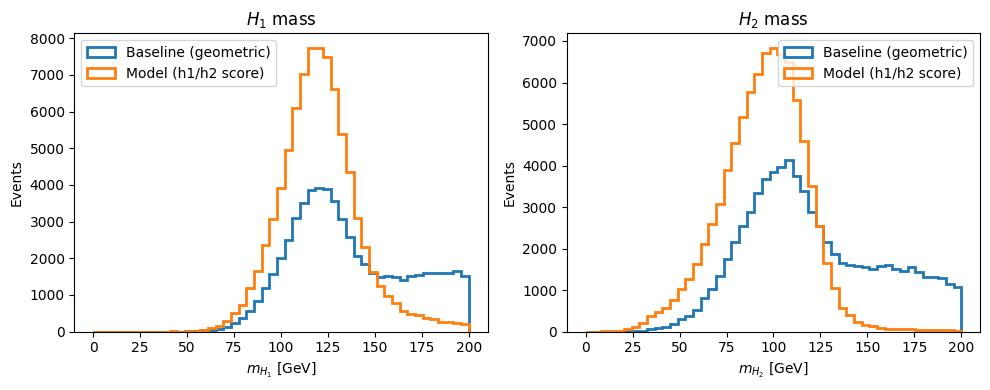

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

bins = np.linspace(0, 200, 50)
axes[0].hist(m_H1_baseline, bins=bins, histtype="step", label="Baseline (geometric)", color="C0", lw=2)
axes[0].hist(m_H1_model[valid_model], bins=bins, histtype="step", label="Model (h1/h2 score)", color="C1", lw=2)
axes[0].set_xlabel(r"$m_{H_1}$ [GeV]")
axes[0].set_ylabel("Events")
axes[0].set_title(r"$H_1$ mass")
axes[0].legend()

axes[1].hist(m_H2_baseline, bins=bins, histtype="step", label="Baseline (geometric)", color="C0", lw=2)
axes[1].hist(m_H2_model[valid_model], bins=bins, histtype="step", label="Model (h1/h2 score)", color="C1", lw=2)
axes[1].set_xlabel(r"$m_{H_2}$ [GeV]")
axes[1].set_ylabel("Events")
axes[1].set_title(r"$H_2$ mass")
axes[1].legend()

plt.tight_layout()
plt.show()

## Exercise 3
1. Modify the model to remove the pairwise mass inductive bias. Does performance degrade significantly? Overlay the new model's results on the mass distribution plots above.